In [137]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.stats import pearsonr
from scipy import stats
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import re
import matplotlib.colors as mcolors
import networkx as nx
from itertools import combinations
import json
import random
from adjustText import adjust_text
import gget
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

# Load in gene sets

In [2]:
### GO biological processes
path_2023 = "../resources/GO_Biological_Process_2023.txt"
path_2025 = "/home/jrcwycy/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt"

geneset_dict = {}

with open(path_2025, "r") as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 1:
            term = parts[0].strip()
            genes = parts[2:] if len(parts) > 2 else []
            genes = [g.strip() for g in genes if g.strip()]
            geneset_dict[term] = genes

geneset = pd.DataFrame.from_dict(geneset_dict, orient='index').T
geneset.head()

,'De Novo' AMP Biosynthetic Process (GO:0044208),'De Novo' Post-Translational Protein Folding (GO:0051084),2-Oxoglutarate Metabolic Process (GO:0006103),3'-UTR-mediated mRNA Destabilization (GO:0061158),3'-UTR-mediated mRNA Stabilization (GO:0070935),3'-Phosphoadenosine 5'-Phosphosulfate Metabolic Process (GO:0050427),4-Hydroxyproline Metabolic Process (GO:0019471),5S Class rRNA Transcription by RNA Polymerase III (GO:0042791),7-Methylguanosine RNA Capping (GO:0009452),7-Methylguanosine Cap Hypermethylation (GO:0036261),...,Wybutosine Biosynthetic Process (GO:0031591),Wybutosine Metabolic Process (GO:0031590),Xenobiotic Catabolic Process (GO:0042178),Xenobiotic Transport (GO:0042908),Xenobiotic Transport Across Blood-Brain Barrier (GO:1990962),Zinc Ion Import Across Plasma Membrane (GO:0071578),Zinc Ion Import Into Organelle (GO:0062111),Zinc Ion Transmembrane Transport (GO:0071577),Zinc Ion Transport (GO:0006829),Zymogen Activation (GO:0031638)
0,ATIC,CCT4,IDH1,UPF1,RBM38,PAPSS1,EGLN2,GTF3C2,RNGTT,SNRPD3,...,TYW5,TYW5,UGT1A10,ABCC5,ABCC2,SLC30A8,SLC30A8,SLC30A8,SLC30A8,FGB
1,PAICS,SDF2L1,PHYH,TRIM71,DAZ4,PAPSS2,GOT2,GTF3C3,RNMT,SNRPD2,...,TYW3,TYW3,GSTM4,SLC22A4,SLC22A1,SLC39A10,SLC30A7,SLC39A1,SLC39A1,FGG
2,PFAS,CCT3,GOT2,RC3H1,TIRAP,SULT1A2,HOGA1,GTF3C4,NCBP1,SNRPF,...,TYW1,TYW1,GSTM3,ABCB1,SLC22A2,SLC39A12,SLC30A4,SLC30A4,SLC30A9,F12
3,ADSS1,HSPA9,IDH2,ZFP36L1,DAZ3,SULT1C4,P4HB,GTF3C5,CMTR2,SNRPG,...,TRMT12,TRMT12,GSTM2,ABCC2,ABCC1,SLC39A6,SLC30A3,SLC30A3,SLC30A4,ZNF160
4,ADSS2,CCT2,ADHFE1,PUM2,YBX3,SULT2A1,PRODH,GTF3C6,RAMAC,SNRPE,...,TYW1B,TYW1B,NANOS1,SLC15A2,ABCG2,SLC39A14,SLC30A6,SLC30A5,SLC30A3,F9


In [27]:
[col for col in geneset if 'muscle' in col.lower()]

pathways = [
    'Muscle Cell Development (GO:0055001)',
    'Muscle Cell Differentiation (GO:0042692)',
    'Muscle Cell Fate Commitment (GO:0042693)',
    'Muscle Organ Development (GO:0007517)',
    'Regulation of Skeletal Muscle Cell Differentiation (GO:2001014)',
]

sub = geneset[pathways]
go_myo_genes = list(set(sub.stack().tolist()))
print(f"N genes: {len(go_myo_genes)}\n")

N genes: 105



In [4]:
[col for col in geneset if 'fibroblast' in col.lower()]


# pathways = [
    

['Cellular Response to Fibroblast Growth Factor Stimulus (GO:0044344)',
 'Fibroblast Growth Factor Receptor Signaling Pathway (GO:0008543)',
 'Negative Regulation of Fibroblast Growth Factor Receptor Signaling Pathway (GO:0040037)',
 'Negative Regulation of Fibroblast Migration (GO:0010764)',
 'Negative Regulation of Fibroblast Proliferation (GO:0048147)',
 'Positive Regulation of Fibroblast Apoptotic Process (GO:2000271)',
 'Positive Regulation of Fibroblast Growth Factor Receptor Signaling Pathway (GO:0045743)',
 'Positive Regulation of Fibroblast Migration (GO:0010763)',
 'Positive Regulation of Fibroblast Proliferation (GO:0048146)',
 'Regulation of Endothelial Cell Chemotaxis to Fibroblast Growth Factor (GO:2000544)',
 'Regulation of Fibroblast Apoptotic Process (GO:2000269)',
 'Regulation of Fibroblast Growth Factor Receptor Signaling Pathway (GO:0040036)',
 'Regulation of Fibroblast Migration (GO:0010762)',
 'Regulation of Fibroblast Proliferation (GO:0048145)',
 'Response to Fi

In [5]:
fpath = "../../resources/clean_marker_genes.csv"

marks = pd.read_csv(fpath)
print(marks.shape)
marks.head()

(699, 5)


,gene,cell_type,source,category,other_categories?
0,APOD,Fibroblast Skin Human,CellMarker,fibroblast,unique
1,APOE,Fibroblast Skin Human,CellMarker,fibroblast,unique
2,CCL19,Fibroblast Skin Human,CellMarker,fibroblast,unique
3,CCL2,Fibroblast Skin Human,CellMarker,fibroblast,muscle
4,CD36,Fibroblast Skin Human,CellMarker,fibroblast,unique


In [6]:
total_myo_genes = marks[marks['category'] == 'muscle']['gene'].unique()
print(len(total_myo_genes))

270


# Load in TF-associated networks

In [7]:
# MYOD1
path1 = "/scratch/indikar_root/indikar1/jrcwycy/HYB/HWG/MYOD_network_1storder_310.csv"
mdf = pd.read_csv(path1, index_col=0)
print(mdf.shape)
display(mdf.head())


# PRRX1
path2 = "/scratch/indikar_root/indikar1/jrcwycy/HYB/HWG/PRRX1_network_1storder_310.csv"
pdf = pd.read_csv(path2, index_col=0)
print(pdf.shape)
display(pdf.head())

(514, 514)


,MYOD1,CD99,KDM1A,PDK4,CALCR,HOXA11,MEOX1,CREBBP,SOX8,IFRD1,...,INS,ENSG00000255071,EID1,SCX,DUX4,PECAM1,MYMX,MYH4,H3-7,DACH1
MYOD1,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
CD99,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
KDM1A,1,0,1,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
PDK4,1,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
CALCR,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


(174, 174)


,PRRX1,COPZ2,METTL13,DCN,SNAI2,VIM,CDH1,PHF23,FOXC1,SYNE2,...,PAX9,TOP1,BMPR2,COL5A2,POU5F1,TWIST2,BGLAP,FOXD1,SCX,GTF2I
PRRX1,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
COPZ2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
METTL13,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
DCN,1,0,0,0,1,1,1,0,0,0,...,0,0,0,1,0,0,1,0,1,0
SNAI2,1,0,0,1,0,1,1,0,1,0,...,0,0,0,1,1,1,0,0,0,0


## Make graphs

In [8]:
# MYOD1
GM = nx.from_pandas_adjacency(mdf, create_using=nx.Graph) # keeps self-loops
GM.remove_edges_from(nx.selfloop_edges(GM)) # remove self-loops

print(f"MYOD1:\nN nodes: {GM.number_of_nodes()}\nN edges: {GM.number_of_edges()}")

# PRRX1
GP = nx.from_pandas_adjacency(pdf, create_using=nx.Graph) # keeps self-loops
GP.remove_edges_from(nx.selfloop_edges(GP)) # remove self-loops

print(f"\nPRRX1:\nN nodes: {GP.number_of_nodes()}\nN edges: {GP.number_of_edges()}")

## get gene lists for 1st order genes
myod_nodes = list(GM.nodes())
prrx_nodes = list(GP.nodes())

MYOD1:
N nodes: 514
N edges: 25648

PRRX1:
N nodes: 174
N edges: 3315


# Compute centralities

Degree:
* Number of direct connections a gene has
* Identifies local hubs / genes participating in many interactions (often broadly involved processes)
* E.g., a gene can interact with many other genes but may not control global structure

Betweenness: 
* How often a node (gene) lies on the shortest paths between other nodes
* Identifies "bottleneck" genes that connect modules
* E.g., a gene may have low degree but high betweenness because it is a bridge

\\

Eigenvector:
* Connection to important nodes (a node connected to highly connected nodes gets a higher score)
* Measures global influence / network regulators

\\

Closeness:
* Centrally located nodes (can reach everyone else in a few steps)

Clustering coefficient:
* How interconnected a gene's neighbors are
* 0 = neighbors don't interact; 1 = neighbors form a clique
* High clustering means the gene sits in a tight functional module
* Global regulators often have low clustering since they connect different modules 

In [42]:
# --- MYOD1 ---
deg1 = dict(GM.degree())
dc1 = nx.degree_centrality(GM)
clust1 = nx.clustering(GM)
betw1 = nx.betweenness_centrality(GM)
eig1 = nx.eigenvector_centrality(GM)
close1 = nx.closeness_centrality(GM)

df1 = pd.DataFrame({
    "degree": pd.Series(deg1),
    "degree_cent": pd.Series(dc1),
    "clustering": pd.Series(clust1),
    "betweenness": pd.Series(betw1),
    "eigenvector": pd.Series(eig1),
    "closeness": pd.Series(close1),
})

display(df1.head())

# --- PRRX1 ---
deg2 = dict(GP.degree())
dc2 = nx.degree_centrality(GP)
clust2 = nx.clustering(GP)
betw2 = nx.betweenness_centrality(GP)
eig2 = nx.eigenvector_centrality(GP)
close2 = nx.closeness_centrality(GP)

df2 = pd.DataFrame({
    "degree": pd.Series(deg2),
    "degree_cent": pd.Series(dc2),
    "clustering": pd.Series(clust2),
    "betweenness": pd.Series(betw2),
    "eigenvector": pd.Series(eig2),
    "closeness": pd.Series(close2),
})

display(df2.head())

,degree,degree_cent,clustering,betweenness,eigenvector,closeness
MYOD1,513,1.000000,0.191391,0.176961,0.111928,1.000000
CD99,36,0.070175,0.749206,0.000042,0.012888,0.518182
KDM1A,126,0.245614,0.600508,0.001230,0.045218,0.570000
PDK4,60,0.116959,0.722034,0.000163,0.021466,0.531056
CALCR,26,0.050682,0.800000,0.000014,0.011952,0.513000


,degree,degree_cent,clustering,betweenness,eigenvector,closeness
PRRX1,173,1.000000,0.211184,0.349783,0.186950,1.000000
COPZ2,19,0.109827,0.959064,0.000024,0.031808,0.529052
METTL13,3,0.017341,0.666667,0.000011,0.004524,0.504373
DCN,62,0.358382,0.628768,0.003697,0.106858,0.609155
SNAI2,70,0.404624,0.616563,0.004040,0.129197,0.626812


# Plots (overview)

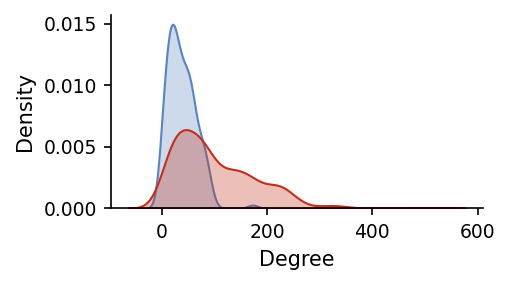

In [43]:
### layered degree distribution

tmp1 = df2.reset_index(names='gene').copy()
# tmp1 = tmp1[tmp1['gene'] != 'PRRX1']

tmp2 = df1.reset_index(names='gene').copy()
# tmp2 = tmp2[tmp2['gene'] != 'MYOD1']


plt.rcParams['figure.dpi'] = 150

deg1 = tmp1['degree']
deg2 = tmp2['degree']

plt.figure(figsize=(3.5,2))

sns.kdeplot(deg1, label='PRRX1 network', fill=True, alpha=0.3, color='#5785C1')
sns.kdeplot(deg2, label='MYOD1 network', fill=True, alpha=0.3, color='#C52E19')


plt.gca().tick_params(axis='both', labelsize=9)

plt.xlabel("Degree")
plt.ylabel("Density")
# plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

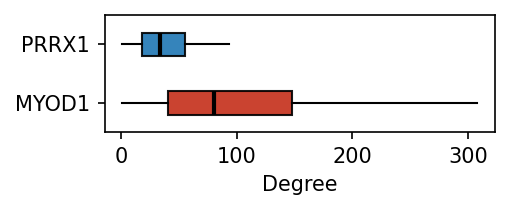

In [149]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = (3.5, 1.5)

fig, ax = plt.subplots()

series = [deg2, deg1]
labels = ["MYOD1", "PRRX1"]
colors = ["#C52E19", "#1F77B4"]

box = ax.boxplot(
    series,
    vert=False,
    patch_artist=True,
    widths=0.4,
    showcaps=False,
    showfliers=False,
    whiskerprops={"linewidth": 1},
    medianprops={"color": "black", "linewidth": 2},
    boxprops={"linewidth": 1}
)

# color boxes
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.9)
    patch.set_edgecolor("black")

ax.set_yticks(range(1, len(labels) + 1))
ax.set_yticklabels(labels)

ax.set_xlabel("Degree")
ax.set_ylabel("")

# sns.despine()
plt.tight_layout()
plt.show()

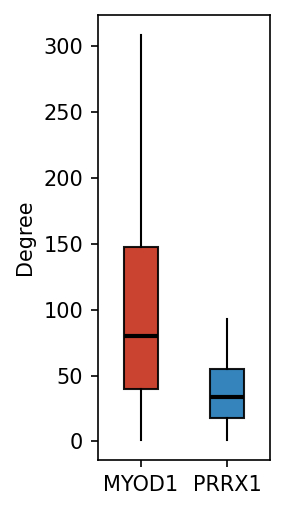

In [153]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = (2, 3.5)

fig, ax = plt.subplots()

series = [deg2, deg1]
labels = ["MYOD1", "PRRX1"]
colors = ["#C52E19", "#1F77B4"]

box = ax.boxplot(
    series,
    # vert=False,
    patch_artist=True,
    widths=0.4,
    showcaps=False,
    showfliers=False,
    whiskerprops={"linewidth": 1},
    medianprops={"color": "black", "linewidth": 2},
    boxprops={"linewidth": 1}
)

# color boxes
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.9)
    patch.set_edgecolor("black")

ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)

ax.set_ylabel("Degree")
ax.set_xlabel("")

# sns.despine()
plt.tight_layout()
plt.show()

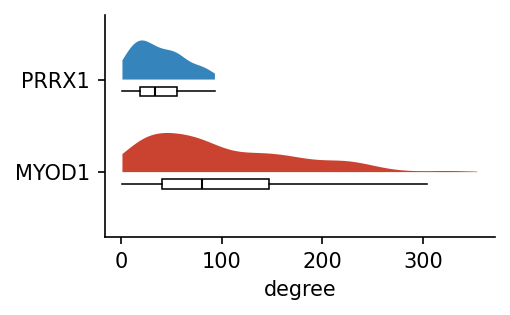

In [26]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = (3.5, 2.2)

fig, ax = plt.subplots()

tmp1 = df2.reset_index(names='gene').copy()
tmp1 = tmp1[tmp1['gene'] != 'PRRX1']

tmp2 = df1.reset_index(names='gene').copy()
tmp2 = tmp2[tmp2['gene'] != 'MYOD1']

deg1 = tmp1['degree']
deg2 = tmp2['degree']

series = [deg2, deg1]
labels = ["MYOD1", "PRRX1"]
colors = ["#C52E19", "#1F77B4"]

violin_width = 0.85
box_width = 0.1
offset = violin_width/6 - box_width/6

for i, vals in enumerate(series):

    # --- Half violin (bottom half now) ---
    parts = ax.violinplot(
        vals,
        positions=[i],
        widths=violin_width,
        vert=False,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )

    for pc in parts['bodies']:
        verts = pc.get_paths()[0].vertices
        mean_y = np.mean(verts[:, 1])
        verts[:, 1] = np.maximum(verts[:, 1], mean_y)
        # verts[:, 1] = np.minimum(verts[:, 1], mean_y)  # keep bottom half
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.9)

    # --- Boxplot (slightly above centerline) ---
    box = ax.boxplot(
        vals,
        positions=[i - offset],
        widths=box_width,
        vert=False,
        patch_artist=True,
        showcaps=False,
        showfliers=False,
        whiskerprops={"linewidth": 0.75},
        medianprops={"color": "black", "linewidth": 1},
        boxprops={'linewidth': 0.75},
    )

    for patch in box['boxes']:
        patch.set_facecolor('white')
        patch.set_edgecolor("black")


ax.set_ylim(-0.7, len(series) - 0.3)

# ax.set_xscale('log')

ax.set_yticks(range(len(series)))
ax.set_yticklabels(labels)

ax.set_xlabel("degree")
ax.set_ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

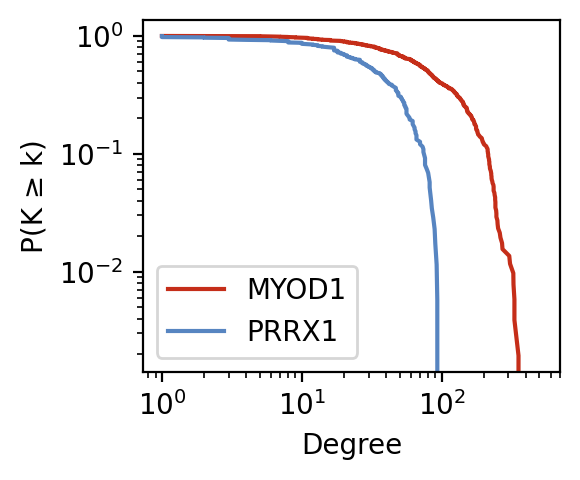

In [8]:
def ccdf(data):
    data = np.sort(data)
    y = 1 - np.arange(1, len(data)+1)/len(data)
    return data, y


# # remove MYOD1/PRRX1
# tmp1 = df1[df1.index != 'MYOD1']
# tmp2 = df2[df2.index != 'PRRX1']

tmp1 = df1.copy()
tmp2 = df2.copy()

x1, y1 = ccdf(tmp1['degree'])
x2, y2 = ccdf(tmp2['degree'])


fig, ax = plt.subplots(figsize=(3,2.5), dpi=200)

ax.plot(x1, y1, label='MYOD1', color='#C52E19')
ax.plot(x2, y2, label='PRRX1', color='#5785C1')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Degree')
ax.set_ylabel('P(K ≥ k)')

ax.legend()

plt.tight_layout()
plt.show()

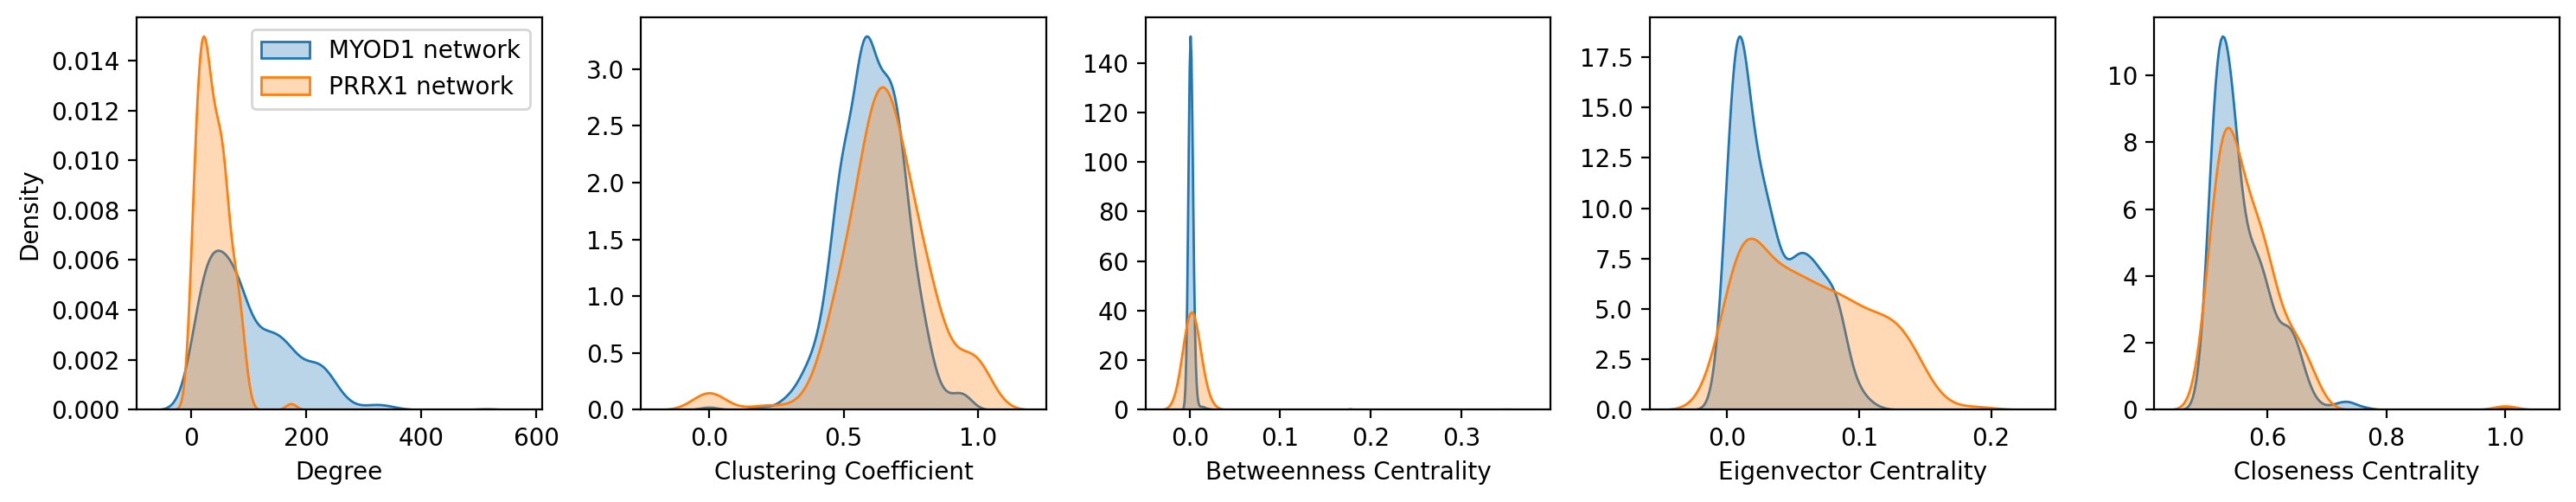

In [9]:
plt.rcParams['figure.dpi'] = 200

fig, axes = plt.subplots(1, 5, figsize=(15,3))

# Degree
sns.kdeplot(df1['degree'], ax=axes[0], label='MYOD1 network', fill=True, alpha=0.3)
sns.kdeplot(df2['degree'], ax=axes[0], label='PRRX1 network', fill=True, alpha=0.3)
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("Density")

# Clustering coefficient
sns.kdeplot(df1['clustering'], ax=axes[1], label='Network 1', fill=True, alpha=0.3)
sns.kdeplot(df2['clustering'], ax=axes[1], label='Network 2', fill=True, alpha=0.3)
axes[1].set_xlabel("Clustering Coefficient")
axes[1].set_ylabel("")

# Betweenness
sns.kdeplot(df1['betweenness'], ax=axes[2], label='Network 1', fill=True, alpha=0.3)
sns.kdeplot(df2['betweenness'], ax=axes[2], label='Network 2', fill=True, alpha=0.3)
axes[2].set_xlabel("Betweenness Centrality")
axes[2].set_ylabel("")

# Eigenvector
sns.kdeplot(df1['eigenvector'], ax=axes[3], label='Network 1', fill=True, alpha=0.3)
sns.kdeplot(df2['eigenvector'], ax=axes[3], label='Network 2', fill=True, alpha=0.3)
axes[3].set_xlabel("Eigenvector Centrality")
axes[3].set_ylabel("")


# Eigenvector
sns.kdeplot(df1['closeness'], ax=axes[4], label='Network 1', fill=True, alpha=0.3)
sns.kdeplot(df2['closeness'], ax=axes[4], label='Network 2', fill=True, alpha=0.3)
axes[4].set_xlabel("Closeness Centrality")
axes[4].set_ylabel("")

axes[0].legend()

plt.tight_layout()
plt.show()

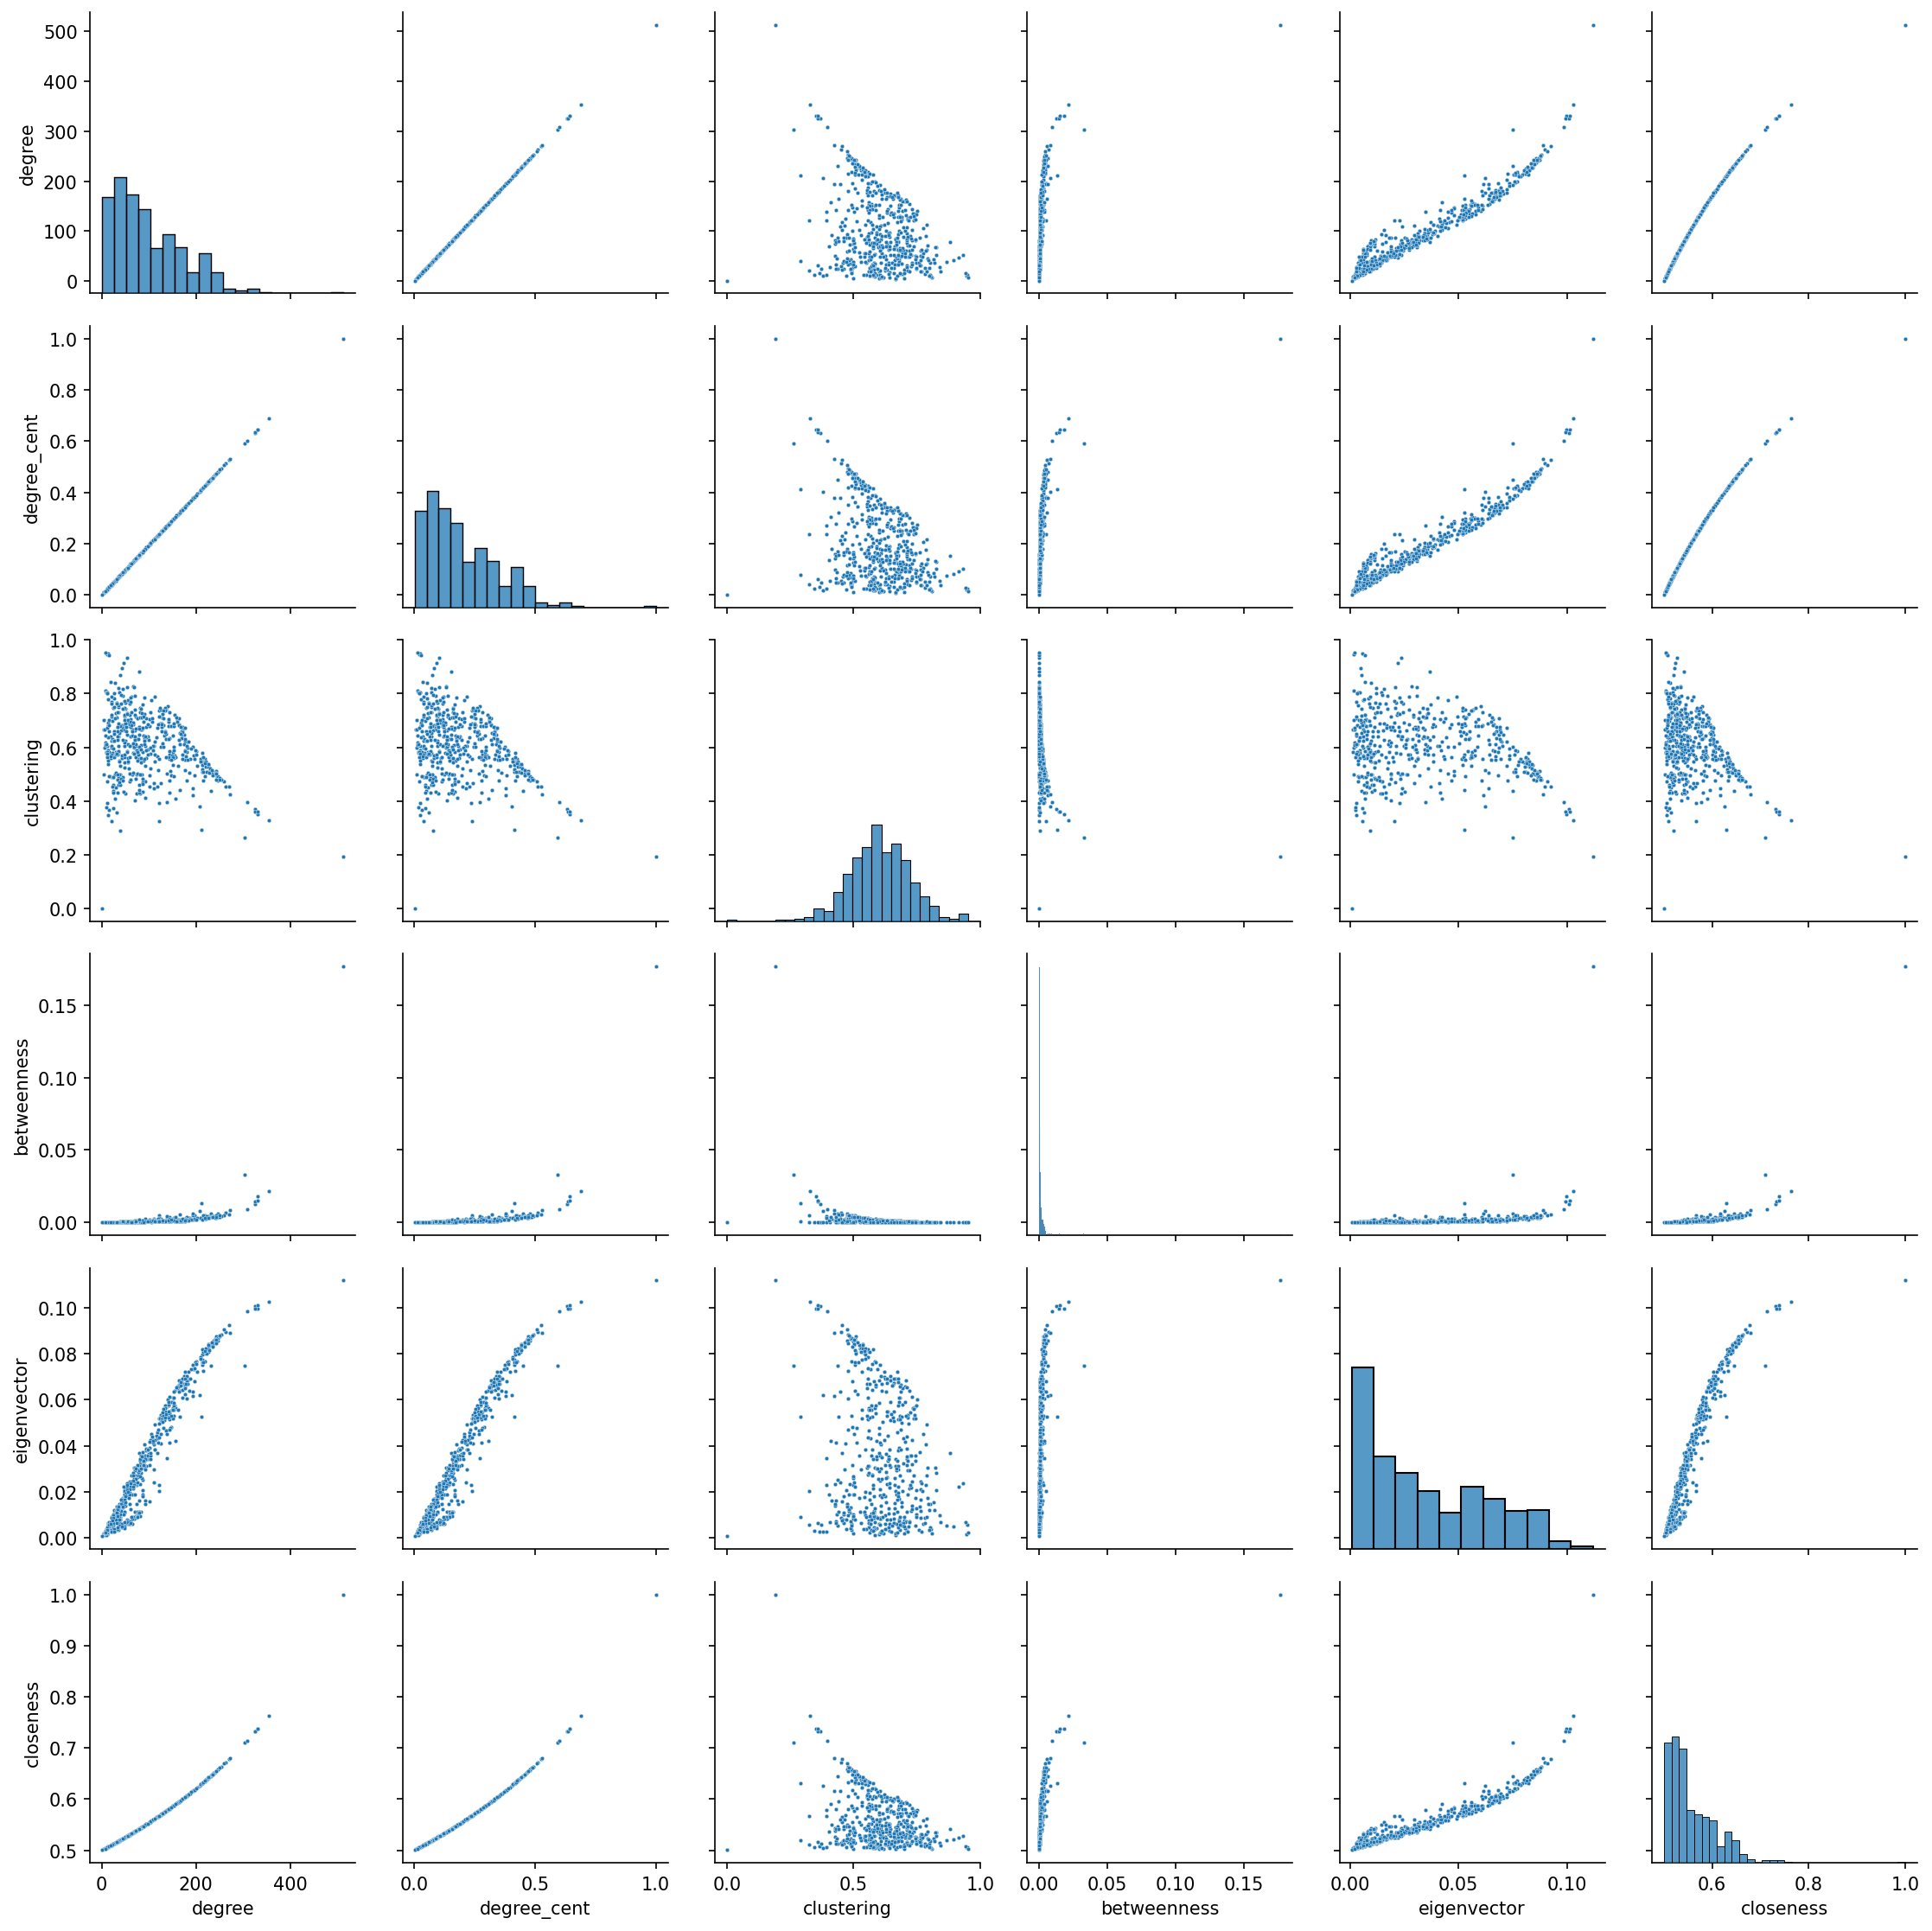

In [45]:
sns.pairplot(
    df1,
    plot_kws={'s': 5},
)

plt.tight_layout()
plt.show()

# Plots (important genes)

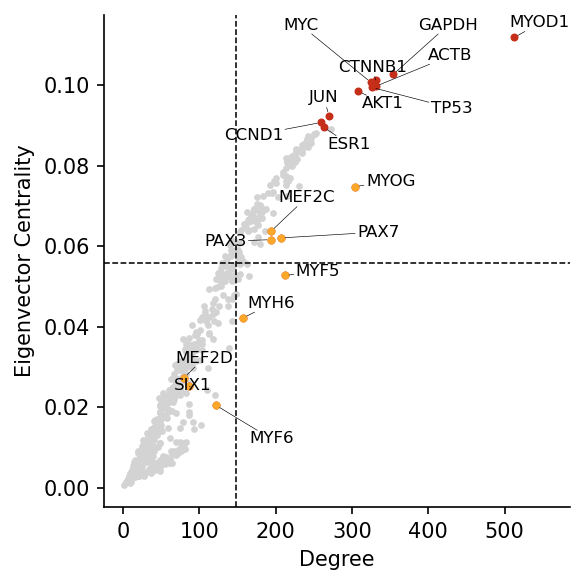

In [21]:
plt.rcParams['figure.dpi'] = 150

fig, ax = plt.subplots(figsize=(4,4))

# scatter all genes
ax.scatter(
    df1["degree"],
    df1["eigenvector"],
    color="lightgray",
    s=5
)

# thresholds
deg_thresh = df1["degree"].quantile(0.75)
eig_thresh = df1["eigenvector"].quantile(0.75)

# quadrant lines
ax.axvline(deg_thresh, color="k", linestyle="--", linewidth=0.75)#, zorder=10)
ax.axhline(eig_thresh, color="k", linestyle="--", linewidth=0.75)#, zorder=10)


# highlight top genes
n_hubs = 10
hub_df = df1.sort_values("eigenvector", ascending=False).head(n_hubs)


# important myogenic genes
myo_plot_genes = ['MYOG', 'MYF5', 'MYF6', 'MEF2D', 'MEF2C', 'SIX1', 'PAX3', 'PAX7', 'MYH6'] 
tmp = df1[df1.index.isin(myo_plot_genes)]

hub_df = pd.concat([hub_df, tmp])


# top ten
ax.scatter(
    hub_df["degree"],
    hub_df["eigenvector"],
    color="#C52E19",
    s=8
)

# other ones
ax.scatter(
    tmp["degree"],
    tmp["eigenvector"],
    color="#FBA72A",
    s=8
)


texts = []
for gene, row in hub_df.iterrows():
    texts.append(
        ax.text(row["degree"], row["eigenvector"], gene,
                fontsize=8, ha="left", va="bottom",)
                # bbox=dict(boxstyle="square,pad=0.1", fc="white", alpha=0.7, ec="none"))
    )

adjust_text(texts,
    expand=(1.45, 2),
    arrowprops=dict(arrowstyle="-", color='k', lw=0.3, shrinkA=1),
    # min_arrow_len=10,
    force_text=(0.5, 0.5),
    expand_axes=True,
)

ax.set_xlabel("Degree")
ax.set_ylabel("Eigenvector Centrality")

# ax.set_xscale('log')

sns.despine()
plt.tight_layout()
plt.show()

In [26]:
total_myo_genes = marks[marks['category'] == 'muscle']['gene'].unique()
print(len(total_myo_genes))

unique_myo_genes = marks[(marks['category'] == 'muscle') & (marks['other_categories?'] == 'unique')]['gene'].unique()
print(len(unique_myo_genes))

270
207


(15, 5)


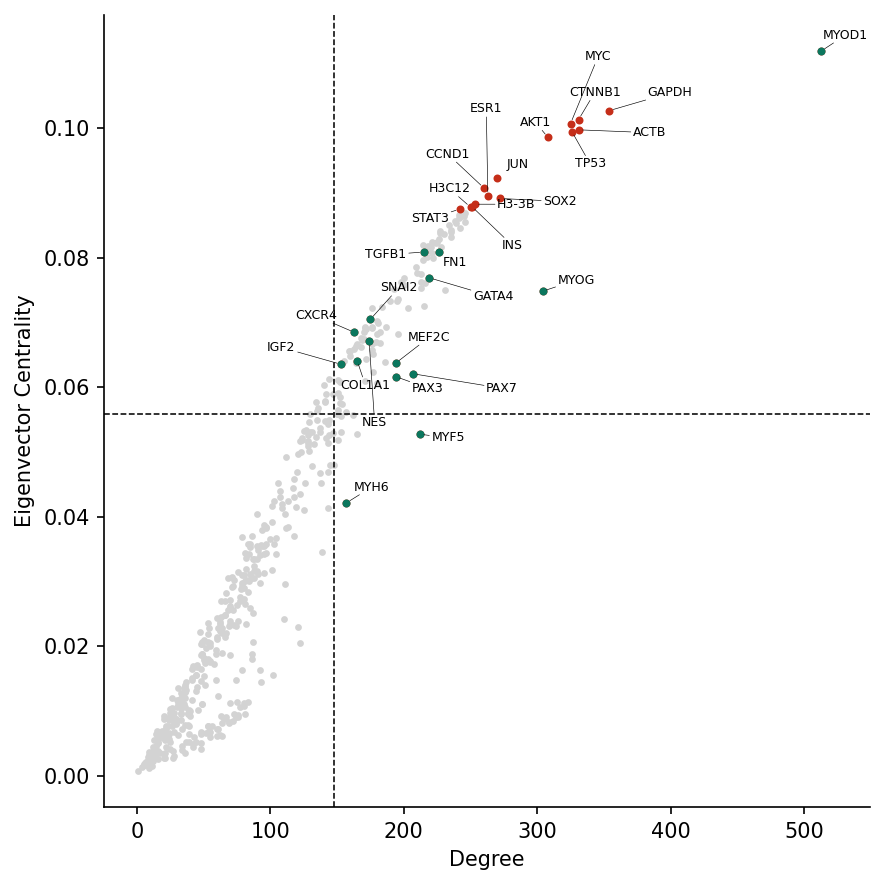

In [54]:
plt.rcParams['figure.dpi'] = 150

fig, ax = plt.subplots(figsize=(6,6))

# scatter all genes
ax.scatter(
    df1["degree"],
    df1["eigenvector"],
    color="lightgray",
    s=5
)

# # thresholds
deg_thresh = df1["degree"].quantile(0.75)
eig_thresh = df1["eigenvector"].quantile(0.75)

# quadrant lines
ax.axvline(deg_thresh, color="k", linestyle="--", linewidth=0.75)#, zorder=10)
ax.axhline(eig_thresh, color="k", linestyle="--", linewidth=0.75)#, zorder=10)


# highlight top genes
n_hubs = 15
hub_df = df1.sort_values("eigenvector", ascending=False).head(n_hubs)


# important myogenic genes
myo_plot_genes = ['MYOG', 'MYF5', 'MYF6', 'MEF2D', 'MEF2C', 'SIX1', 'PAX3', 'PAX7'] 
# tmp = df1[df1.index.isin(myo_plot_genes)]

tmp = df1[df1.index.isin(total_myo_genes)]

tmp1 = tmp[(tmp['degree'] > deg_thresh) | (tmp['eigenvector'] > eig_thresh)]

print(tmp1.shape)

hub_df = pd.concat([hub_df, tmp1])

hub_df = hub_df.drop_duplicates()


ax.scatter(
    hub_df["degree"],
    hub_df["eigenvector"],
    color="#C52E19",
    s=8
)

ax.scatter(
    tmp1["degree"],
    tmp1["eigenvector"],
    color="#0B775E",
    s=8
)


texts = []
for gene, row in hub_df.iterrows():
    texts.append(
        ax.text(row["degree"], row["eigenvector"], gene,
                fontsize=6, ha="left", va="bottom",)
                # bbox=dict(boxstyle="square,pad=0.1", fc="white", alpha=0.7, ec="none"))
    )

adjust_text(texts,
    expand=(1.45, 2),
    arrowprops=dict(arrowstyle="-", color='k', lw=0.3, shrinkA=1),
    # min_arrow_len=10,
    force_text=(0.5, 0.5),
    expand_axes=True,
)

ax.set_xlabel("Degree")
ax.set_ylabel("Eigenvector Centrality")

# ax.set_xscale('log')

sns.despine()
plt.tight_layout()
plt.show()

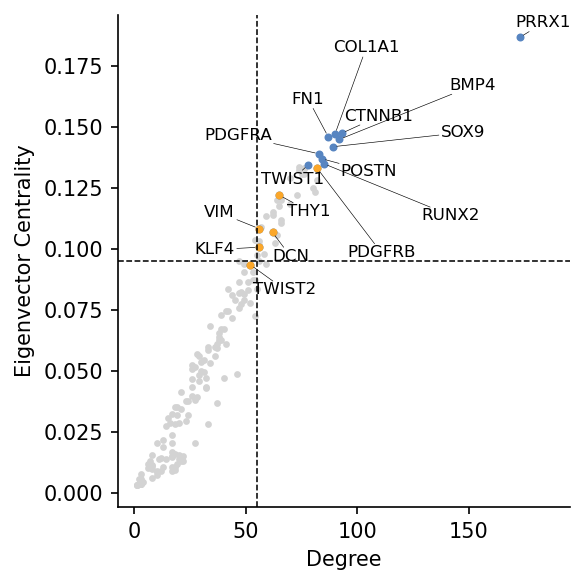

In [23]:
plt.rcParams['figure.dpi'] = 150

fig, ax = plt.subplots(figsize=(4,4))

# scatter all genes
ax.scatter(
    df2["degree"],
    df2["eigenvector"],
    color="lightgray",
    s=5
)

# thresholds
deg_thresh = df2["degree"].quantile(0.75)
eig_thresh = df2["eigenvector"].quantile(0.75)

# quadrant lines
ax.axvline(deg_thresh, color="k", linestyle="--", linewidth=0.75)#, zorder=10)
ax.axhline(eig_thresh, color="k", linestyle="--", linewidth=0.75)#, zorder=10)


# highlight top genes
n_hubs = 10
hub_df = df2.sort_values("eigenvector", ascending=False).head(n_hubs)


# important fib genes
fib_plot_genes = ['DCN', 'VIM', 'PDGFRB', 'TWIST2', 'KLF4', 'KLF5', 'THY1'] 
tmp = df2[df2.index.isin(fib_plot_genes)]

hub_df = pd.concat([hub_df, tmp])



ax.scatter(
    hub_df["degree"],
    hub_df["eigenvector"],
    color="#5785C1",
    s=8
)

ax.scatter(
    tmp["degree"],
    tmp["eigenvector"],
    color="#FBA72A",
    s=8
)


texts = []
for gene, row in hub_df.iterrows():
    texts.append(
        ax.text(row["degree"], row["eigenvector"], gene,
                fontsize=8, ha="left", va="bottom",)
                # bbox=dict(boxstyle="square,pad=0.1", fc="white", alpha=0.7, ec="none"))
    )

adjust_text(texts,
    expand=(1.45, 2),
    arrowprops=dict(arrowstyle="-", color='k', lw=0.3, shrinkA=1),
    # min_arrow_len=10,
    force_text=(0.5, 0.5),
    expand_axes=True,
)

ax.set_xlabel("Degree")
ax.set_ylabel("Eigenvector Centrality")

sns.despine()
plt.tight_layout()
plt.show()

In [55]:
total_fib_genes = marks[marks['category'] == 'fibroblast']['gene'].unique()
print(len(total_fib_genes))

254


(21, 5)


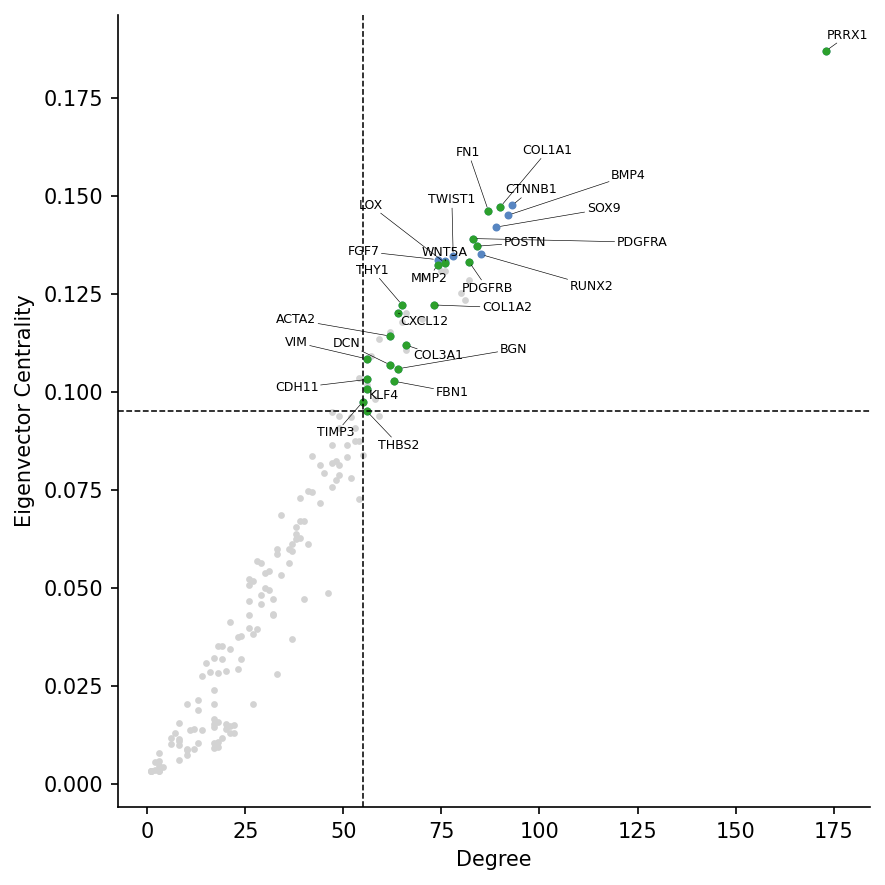

In [58]:
plt.rcParams['figure.dpi'] = 150

fig, ax = plt.subplots(figsize=(6,6))

# scatter all genes
ax.scatter(
    df2["degree"],
    df2["eigenvector"],
    color="lightgray",
    s=5
)

# # thresholds
deg_thresh = df2["degree"].quantile(0.75)
eig_thresh = df2["eigenvector"].quantile(0.75)

# quadrant lines
ax.axvline(deg_thresh, color="k", linestyle="--", linewidth=0.75)#, zorder=10)
ax.axhline(eig_thresh, color="k", linestyle="--", linewidth=0.75)#, zorder=10)


# highlight top genes
n_hubs = 15
hub_df = df2.sort_values("eigenvector", ascending=False).head(n_hubs)


# important myogenic genes

tmp = df2[df2.index.isin(total_fib_genes)]

tmp1 = tmp[(tmp['degree'] > deg_thresh) | (tmp['eigenvector'] > eig_thresh)]

print(tmp1.shape)

hub_df = pd.concat([hub_df, tmp1])
hub_df = hub_df.drop_duplicates(keep='first')


ax.scatter(
    hub_df["degree"],
    hub_df["eigenvector"],
    color="#5785C1",
    s=8
)

ax.scatter(
    tmp1["degree"],
    tmp1["eigenvector"],
    color="tab:green",
    s=8
)


texts = []
for gene, row in hub_df.iterrows():
    texts.append(
        ax.text(row["degree"], row["eigenvector"], gene,
                fontsize=6, ha="left", va="bottom",)
                # bbox=dict(boxstyle="square,pad=0.1", fc="white", alpha=0.7, ec="none"))
    )

adjust_text(texts,
    expand=(1.45, 2),
    arrowprops=dict(arrowstyle="-", color='k', lw=0.3, shrinkA=1),
    # min_arrow_len=10,
    force_text=(0.5, 0.5),
    expand_axes=True,
)

ax.set_xlabel("Degree")
ax.set_ylabel("Eigenvector Centrality")

# ax.set_xscale('log')

sns.despine()
plt.tight_layout()
plt.show()

(90, 5)


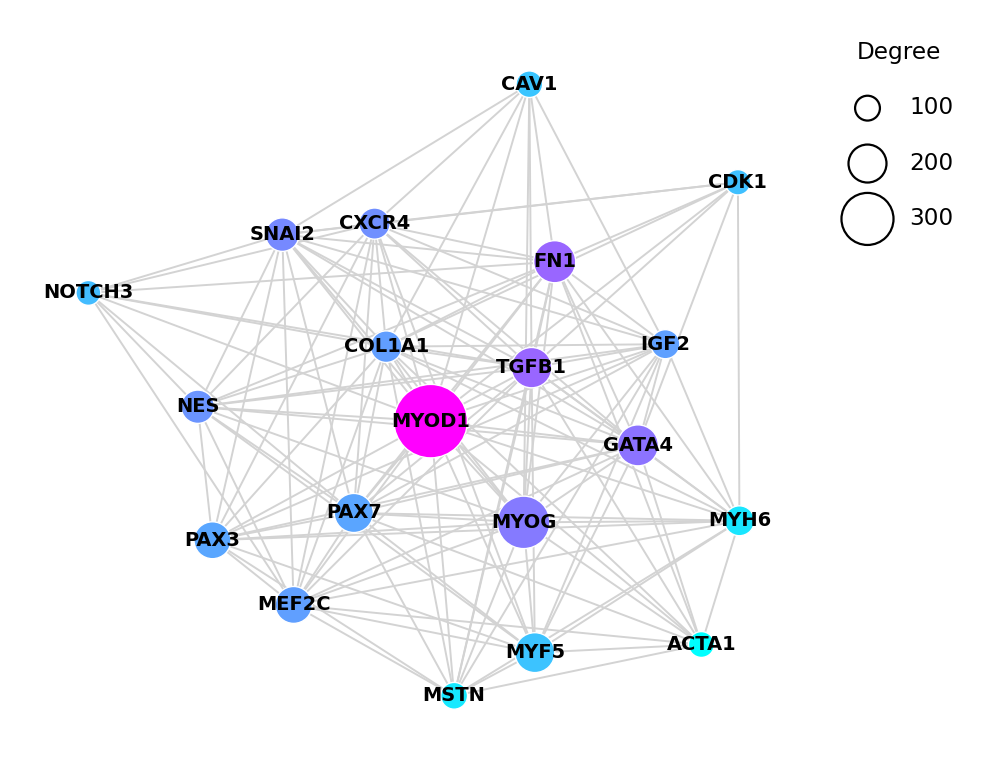

In [38]:
fig, ax = plt.subplots(figsize=(5,4), dpi=200)
fig.subplots_adjust(right=0.78)

sort_col = 'degree'
n_genes = 20

tmp = df1[df1.index.isin(total_myo_genes)]
print(tmp.shape)

top20_nodes = tmp.sort_values(by=sort_col, ascending=False).head(n_genes).index.to_list()
# top20_nodes

subG = GM.subgraph(top20_nodes)
# pos_sub = nx.spring_layout(subG, seed=42)
pos_sub = nx.kamada_kawai_layout(subG)


# Align attributes to the node order used by NetworkX drawing
node_order = list(subG.nodes())
attrs = tmp.reindex(node_order)

# Node size ~ degree (scale to a nice visual range)
deg = attrs["degree"].to_numpy(dtype=float)
deg_min, deg_max = np.nanmin(deg), np.nanmax(deg)

def degree_to_size(d, out_min=80, out_max=700):
    # maps degree values -> marker areas, same as np.interp(...)
    return np.interp(d, (deg_min, deg_max), (out_min, out_max))

sizes = np.interp(deg, (deg_min, deg_max), (80, 700))  # tune (80,700)

# Node color ~ eigenvector
eig = attrs["eigenvector"].to_numpy(dtype=float)


nodes = nx.draw_networkx_nodes(
    subG, pos=pos_sub,
    node_size=sizes,
    node_color=eig,
    cmap="cool",
    vmin=np.nanmin(eig), vmax=np.nanmax(eig),
    linewidths=0.5, edgecolors="white"
)

nx.draw_networkx_edges(
    subG, pos=pos_sub, 
    edge_color="lightgray", width=0.7, #alpha=0.7,
)

nx.draw_networkx_labels(
    subG, pos=pos_sub,
    font_size=7, font_weight="bold",
)

# text_items = nx.draw_networkx_labels(
#     subG, pos=pos_sub,
#     font_size=7, font_weight="bold", ax=ax,
# )

# # add a white outline to each label
# for t in text_items.values():
#     t.set_path_effects([pe.Stroke(linewidth=1, foreground="white"),
#                         pe.Normal()])
    
## Node size legend
# # legend_degs = np.unique(np.round(np.quantile(deg, [0.25, 0.5, 0.75]), 2))
# legend_degs = np.unique(np.rint(np.quantile(deg, [0.25, 0.5, 0.75])).astype(int))
# legend_sizes = np.interp(legend_degs, (deg_min, deg_max), (80, 700))  # must match your scaling
# legend_sizes = np.rint(legend_sizes).astype(int)

# handles = [plt.scatter([], [], s=int(s), facecolors="none", edgecolors="black", linewidths=0.8) for s in legend_sizes]
# labels = [f"{d:g}" for d in legend_degs]

# ax.legend(
#     handles, labels, title="Node size (degree)",
#     loc="upper left", bbox_to_anchor=(1.02, 1.0),
#     frameon=False, borderaxespad=0.0, labelspacing=1.0, handletextpad=0.8,
#     fontsize='small', title_fontsize='small',
# )

legend_degs = [100, 200, 300]  # <-- set whatever integers you want

legend_sizes = np.rint(degree_to_size(np.array(legend_degs, dtype=float))).astype(int)

handles = [
    ax.scatter([], [], s=int(s), facecolors="none", edgecolors="black", linewidths=0.8)
    for s in legend_sizes
]
labels = [str(d) for d in legend_degs]

ax.legend(
    handles, labels, title="Degree",
    loc="upper left", bbox_to_anchor=(1.02, 1.0),
    frameon=False, fontsize="small", title_fontsize="small", labelspacing=1.4
)

plt.gca().axis("off")
plt.tight_layout()
plt.show()

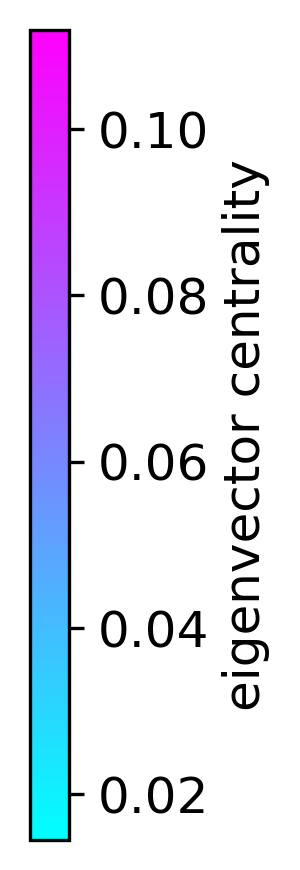

In [20]:
vmin = np.nanmin(eig)
vmax = np.nanmax(eig)

cmap = plt.cm.cool
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 1.1, 3
fig, ax = plt.subplots()

cbar = plt.colorbar(
    sm,
    cax=ax,
    orientation='vertical',
    shrink=0.5,
)

# cbar.set_ticks([vmin, -1, 0, 1, vmax])
# cbar.set_ticklabels([vmin, f'≥ {vmax}'])
cbar.ax.tick_params(labelsize=12)
cbar.set_label('eigenvector centrality', rotation=90, labelpad=3, fontsize=12)

plt.tight_layout()
plt.show()

In [25]:
df2.head()

,degree,clustering,betweenness,eigenvector,closeness
PRRX1,173,0.211184,0.349783,0.186950,1.000000
COPZ2,19,0.959064,0.000024,0.031808,0.529052
METTL13,3,0.666667,0.000011,0.004524,0.504373
DCN,62,0.628768,0.003697,0.106858,0.609155
SNAI2,70,0.616563,0.004040,0.129197,0.626812


In [28]:
full_myo_genes = list(set(go_myo_genes) | set(total_myo_genes))

print(len(go_myo_genes))
print(len(total_myo_genes))
print(len(full_myo_genes))

105
270
343


In [100]:
total_fib_genes = marks[marks['category'] == 'fibroblast']['gene'].unique()
print(len(total_fib_genes))

254


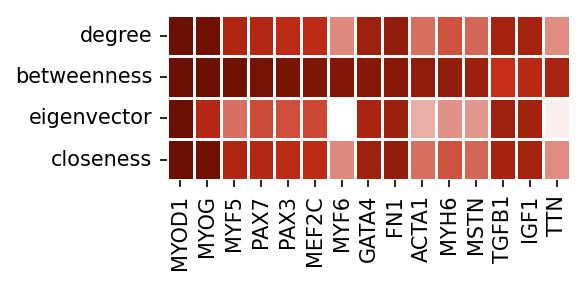

In [146]:
tmp = df1.rank(pct=True)

# filter for genes of interest
tmp = tmp[tmp.index.isin(full_myo_genes)]

# drop unwanted measures
tmp = tmp.drop(columns=['degree_cent', 'clustering'])


tmp['max_centrality'] = tmp.max(axis=1) # takes max centrality measure for each gene

n_top = 15

top10 = tmp.sort_values(by='max_centrality', ascending=False).head(n_top)

top10 = top10.drop(columns='max_centrality')



custom_cmap = LinearSegmentedColormap.from_list(
    "custom_cmap",
    [(0.0, 'white'), (0.75, '#C52E19'), (1.0, '#6A0F02')]
)


plt.figure(figsize=(4, 2))
ax = sns.heatmap(
    top10.T,
    cmap=custom_cmap,
    alpha=1,
    linewidths=0.485,
    linecolor="white",
    cbar=False,
    # cbar_kws={"label": "Centrality (percentile)", 'shrink': 0.8},
    # vmin=0.3,
    # vmax=1,
)

ax.set_xlabel("")
ax.set_ylabel("")
# ax.set_xticklabels(["MYOD1", "PRRX1"], rotation=90)

# ax.set_yticks([i + 0.5 for i in range(len(mat))])
# ax.set_yticklabels(mat.index.to_list(), fontsize=8, va='center')


plt.tight_layout()
plt.show()

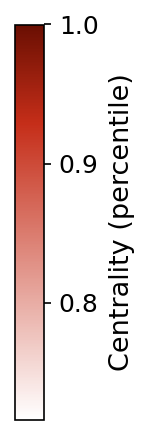

In [144]:
# colorbars
vmin = top10.min().min()
vmax = top10.max().max()

norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
sm.set_array([])

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 1.1, 3
fig, ax = plt.subplots()

cbar = plt.colorbar(
    sm,
    cax=ax,
    orientation='vertical',
    shrink=0.5,
)

cbar.ax.tick_params(labelsize=12)
cbar.ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
# cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
cbar.set_label('Centrality (percentile)', rotation=90, labelpad=5, fontsize=13)

plt.tight_layout()
plt.show()


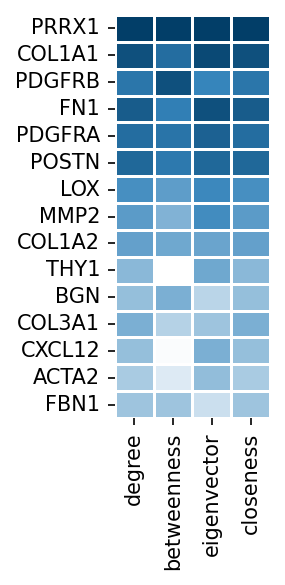

In [135]:
tmp = df2.rank(pct=True)

# filter for genes of interest
tmp = tmp[tmp.index.isin(total_fib_genes)]

# drop unwanted measures
tmp = tmp.drop(columns=['degree_cent', 'clustering'])


tmp['max_centrality'] = tmp.max(axis=1) # takes max centrality measure for each gene

n_top = 15

top10 = tmp.sort_values(by='max_centrality', ascending=False).head(n_top)

top10 = top10.drop(columns='max_centrality')


custom_cmap = LinearSegmentedColormap.from_list(
    "custom_cmap",
    [(0.0, 'white'), (0.75, '#3584BB'), (1.0, '#023E68')]
)


plt.figure(figsize=(2, 4))
ax = sns.heatmap(
    top10,
    cmap=custom_cmap,
    # cmap="Oranges",
    linewidths=0.485,
    linecolor="white",
    cbar=False,
    # cbar_kws={"label": "Centrality (percentile)", 'shrink': 0.8},
    # vmin=muscle_vmin,
    # vmax=1,
)

ax.set_xlabel("")
ax.set_ylabel("")
# ax.set_xticklabels(["MYOD1", "PRRX1"], rotation=90)

# ax.set_yticks([i + 0.5 for i in range(len(mat))])
# ax.set_yticklabels(mat.index.to_list(), fontsize=8, va='center')


plt.tight_layout()
plt.show()

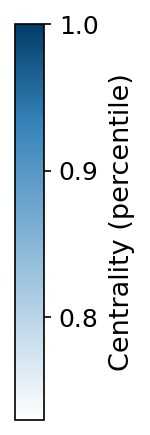

In [141]:
# colorbars
vmin = top10.min().min()
vmax = top10.max().max()

norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
sm.set_array([])

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 1.1, 3
fig, ax = plt.subplots()

cbar = plt.colorbar(
    sm,
    cax=ax,
    orientation='vertical',
    shrink=0.5,
)

cbar.ax.tick_params(labelsize=12)
cbar.ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
# cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
cbar.set_label('Centrality (percentile)', rotation=90, labelpad=5, fontsize=13)

plt.tight_layout()
plt.show()


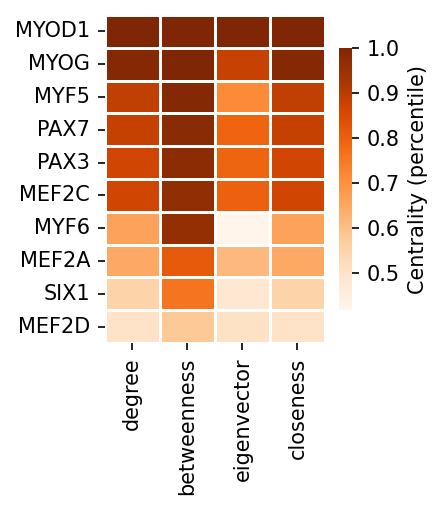

In [91]:
# ## muscle / fibroblast marker genes and all centrality measures (heatmap ?)
# # key muscle genes
# key_myo_genes = [
#     'MYOD1', 'MYOG', 'MYF5', 'MYF6', # core myogenic regulatory factors (MRFs)
    
#     'SIX1', 'PAX3', 'PAX7', # core developmental
    
#     'MEF2C', 'MEF2A', 'MEF2D',
    
# ]

# # convert to percentile (0-1) per measure
# tmp = df1.rank(pct=True)

# # filter for genes of interest
# tmp = tmp[tmp.index.isin(key_myo_genes)]

# # drop unwanted measures
# tmp = tmp.drop(columns=['degree_cent', 'clustering'])

# # sort for plotting
# tmp = tmp.sort_values(by='degree', ascending=False)

# # tmp = tmp.T


# plt.figure(figsize=(3, 3.5))
# ax = sns.heatmap(
#     tmp,
#     # cmap=custom_cmap,
#     cmap="Oranges",
#     linewidths=0.485,
#     linecolor="white",
#     cbar_kws={"label": "Centrality (percentile)", 'shrink': 0.8},
#     # vmin=0.3,
#     # vmax=1,
# )

# ax.set_xlabel("")
# ax.set_ylabel("")
# # ax.set_xticklabels(["MYOD1", "PRRX1"], rotation=90)

# # ax.set_yticks([i + 0.5 for i in range(len(mat))])
# # ax.set_yticklabels(mat.index.to_list(), fontsize=8, va='center')


# plt.tight_layout()
# plt.show()

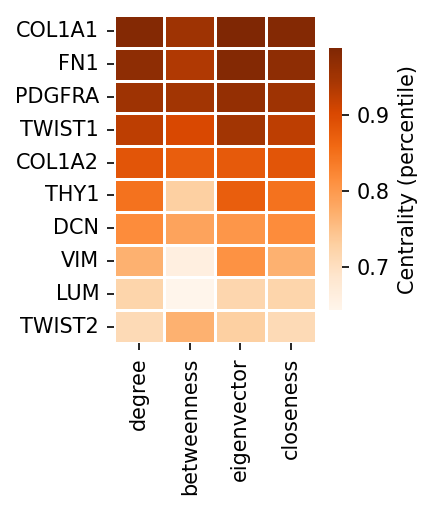

In [92]:
# ## muscle / fibroblast marker genes and all centrality measures (heatmap ?)
# # key fibroblast genes
# key_fibro_genes = [
#     'COL1A1', 'COL1A2', 'DCN', 'VIM', 'LUM',
#     'PDGFRA', 'TWIST1', 'TWIST2', 'THY1', 'FN1',
# ]

# # convert to percentile (0-1) per measure
# tmp = df2.rank(pct=True)

# # filter for genes of interest
# tmp = tmp[tmp.index.isin(key_fibro_genes)]

# # drop unwanted measures
# tmp = tmp.drop(columns=['degree_cent', 'clustering'])

# # sort for plotting
# tmp = tmp.sort_values(by='degree', ascending=False)

# # tmp = tmp.T

# plt.figure(figsize=(3, 3.5))
# ax = sns.heatmap(
#     tmp,
#     # cmap=custom_cmap,
#     cmap="Oranges",
#     linewidths=0.485,
#     linecolor="white",
#     cbar_kws={"label": "Centrality (percentile)", 'shrink': 0.8},
#     # vmin=0.3,
#     # vmax=1,
# )

# ax.set_xlabel("")
# ax.set_ylabel("")
# # ax.set_xticklabels(["MYOD1", "PRRX1"], rotation=90)

# # ax.set_yticks([i + 0.5 for i in range(len(mat))])
# # ax.set_yticklabels(mat.index.to_list(), fontsize=8, va='center')


# plt.tight_layout()
# plt.show()

## Enrichr

In [150]:
# pd.set_option('display.max_colwidth', None)

sort_cols = df1.columns.tolist()

n_genes = 50
gene_lists = {}

for col in sort_cols:
    gene_list = df1.sort_values(by=col, ascending=False).head(n_genes).index.tolist()
    gene_lists[col] = gene_list
    
# database = "PanglaoDB_Augmented_2021"
database = "GO_Biological_Process_2025"
# database="Reactome_Pathways_2024"
# database="KEGG_2021_Human"
# database='MSigDB_Hallmark_2020' 

for column, genes in gene_lists.items():
    
    print(f"{column}")

    enr = gget.enrichr(
        genes,
        database,
        save=False,
    )

    enr = enr[enr['adj_p_val'] < 0.05]
    # print(enr.columns)

    enr['adj_score'] = abs(np.log(enr['adj_p_val']) * enr['z_score'])

    # enr = enr.sort_values(by='adj_score', ascending=False)

    display(enr[['path_name', 'overlapping_genes', 'adj_p_val', 'z_score', 'combined_score', 'adj_score']].head(10))

    # break

17:13:56 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


degree


,path_name,overlapping_genes,adj_p_val,z_score,combined_score,adj_score
0,Positive Regulation of Transcription by RNA Po...,"[NOTCH1, HDAC1, PTEN, GATA4, TNF, HIF1A, FOXO1...",9.577351e-27,35.516299,2387.628636,2127.795533
1,Positive Regulation of RNA Biosynthetic Proces...,"[NOTCH1, HDAC1, GATA4, TNF, HIF1A, FOXO1, SOX2...",9.214119e-25,39.772054,2464.540033,2201.140205
2,Positive Regulation of DNA-templated Transcrip...,"[NOTCH1, HDAC1, PTEN, GATA4, TNF, HIF1A, FOXO1...",1.102658e-23,26.778315,1582.036165,1415.548121
3,Regulation of miRNA Transcription (GO:1902893),"[JUN, SMAD3, STAT3, FOS, KLF4, ESR1, TNF, HIF1...",1.898283e-19,131.902601,6468.207554,5686.079325
4,Positive Regulation of miRNA Metabolic Process...,"[JUN, IL6, SMAD3, MYC, STAT3, PPARG, FOS, KLF4...",1.062445e-18,153.342747,7221.278729,6346.236685
5,Positive Regulation of Macromolecule Biosynthe...,"[GSK3B, SMAD4, SMAD3, NOTCH1, CDKN2A, HDAC1, S...",1.549985e-18,35.778226,1664.847100,1467.203743
6,Regulation of Transcription by RNA Polymerase ...,"[NOTCH1, HDAC1, PTEN, GATA4, TNF, HIF1A, FOXO1...",1.204225e-17,15.526785,688.272625,604.894203
7,Regulation of Gene Expression (GO:0010468),"[GSK3B, NOTCH1, HDAC1, GATA4, TNF, HIF1A, INS,...",1.564363e-17,18.546549,814.803842,717.685917
8,Negative Regulation of DNA-templated Transcrip...,"[NOTCH1, HDAC1, GATA4, TNF, HIF1A, FOXO1, SOX2...",1.638678e-17,19.336391,846.329014,747.352622
9,Positive Regulation of miRNA Transcription (GO...,"[JUN, IL6, SMAD3, MYC, STAT3, PPARG, FOS, KLF4...",1.791353e-17,156.021368,6798.517758,6016.336084


17:13:57 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


degree_cent


...

eigenvector


,path_name,overlapping_genes,adj_p_val,z_score,combined_score,adj_score
0,Positive Regulation of Transcription by RNA Po...,"[NOTCH1, PTEN, HIF1A, TNF, FOXO1, SOX2, MYC, A...",9.903034e-24,29.900839,1802.274925,1583.823577
1,Positive Regulation of RNA Biosynthetic Proces...,"[NOTCH1, HIF1A, TNF, FOXO1, SOX2, MYC, SMAD2, ...",3.484345e-23,36.641509,2137.075363,1894.775583
2,Positive Regulation of DNA-templated Transcrip...,"[NOTCH1, PTEN, HIF1A, TNF, FOXO1, SOX2, MYC, A...",2.776971e-22,24.555066,1371.222650,1218.803270
3,Regulation of miRNA Transcription (GO:1902893),"[JUN, SMAD3, TGFB1, STAT3, FOS, KLF4, ESR1, HI...",1.321621e-21,148.809829,8034.985718,7154.096163
4,Positive Regulation of miRNA Metabolic Process...,"[JUN, SMAD3, TGFB1, STAT3, FOS, KLF4, HIF1A, T...",6.325446e-21,174.885135,9130.075845,8133.856293
5,Positive Regulation of Macromolecule Biosynthe...,"[GSK3B, SMAD4, SMAD3, NOTCH1, TGFB1, CDKN2A, E...",4.064701e-20,39.034826,1958.122014,1742.880058
6,Positive Regulation of miRNA Transcription (GO...,"[JUN, IL6, SMAD3, TGFB1, MYC, STAT3, PPARG, FO...",1.487016e-19,179.684211,8752.830309,7789.731946
7,Positive Regulation of Gene Expression (GO:001...,"[GSK3B, SMAD4, SMAD3, NOTCH1, TGFB1, CDKN2A, E...",1.831529e-18,31.304487,1442.128826,1278.518475
8,Regulation of Gene Expression (GO:0010468),"[GSK3B, NOTCH1, HIF1A, TNF, INS, SOX2, MYC, AK...",1.376677e-17,18.546549,814.803842,720.056286
9,Regulation of Transcription by RNA Polymerase ...,"[NOTCH1, PTEN, HIF1A, TNF, FOXO1, SOX2, CCND1,...",1.578988e-15,13.037191,508.851768,444.333438


17:13:58 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


closeness


,path_name,overlapping_genes,adj_p_val,z_score,combined_score,adj_score
0,Positive Regulation of Transcription by RNA Po...,"[NOTCH1, HDAC1, PTEN, GATA4, TNF, HIF1A, FOXO1...",9.577351e-27,35.516299,2387.628636,2127.795533
1,Positive Regulation of RNA Biosynthetic Proces...,"[NOTCH1, HDAC1, GATA4, TNF, HIF1A, FOXO1, SOX2...",9.214119e-25,39.772054,2464.540033,2201.140205
2,Positive Regulation of DNA-templated Transcrip...,"[NOTCH1, HDAC1, PTEN, GATA4, TNF, HIF1A, FOXO1...",1.102658e-23,26.778315,1582.036165,1415.548121
3,Regulation of miRNA Transcription (GO:1902893),"[JUN, SMAD3, STAT3, FOS, KLF4, ESR1, TNF, HIF1...",1.898283e-19,131.902601,6468.207554,5686.079325
4,Positive Regulation of miRNA Metabolic Process...,"[JUN, IL6, SMAD3, MYC, STAT3, PPARG, FOS, KLF4...",1.062445e-18,153.342747,7221.278729,6346.236685
5,Positive Regulation of Macromolecule Biosynthe...,"[GSK3B, SMAD4, SMAD3, NOTCH1, CDKN2A, HDAC1, S...",1.549985e-18,35.778226,1664.847100,1467.203743
6,Regulation of Transcription by RNA Polymerase ...,"[NOTCH1, HDAC1, PTEN, GATA4, TNF, HIF1A, FOXO1...",1.204225e-17,15.526785,688.272625,604.894203
7,Regulation of Gene Expression (GO:0010468),"[GSK3B, NOTCH1, HDAC1, GATA4, TNF, HIF1A, INS,...",1.564363e-17,18.546549,814.803842,717.685917
8,Negative Regulation of DNA-templated Transcrip...,"[NOTCH1, HDAC1, GATA4, TNF, HIF1A, FOXO1, SOX2...",1.638678e-17,19.336391,846.329014,747.352622
9,Positive Regulation of miRNA Transcription (GO...,"[JUN, IL6, SMAD3, MYC, STAT3, PPARG, FOS, KLF4...",1.791353e-17,156.021368,6798.517758,6016.336084


# Specific genes

In [88]:
mdf1 = df1.copy()

mdf1['is_mark_muscle'] = mdf1.index.isin(total_myo_genes)
mdf1['is_mark_fib'] = mdf1.index.isin(total_fib_genes)



sort_col = 'eigenvector'

mdf1 = mdf1.sort_values(by=sort_col, ascending=False)#.reset_index(names='gene')

if 'gene' not in mdf1.columns:
    mdf1 = mdf1.reset_index(names='gene')
    
mdf1['rank'] = mdf1.index + 1

mdf1.head()

n_top = 10

top_overall = mdf1.head(n_top)['gene'].unique()

print(f"Top 10 genes by {sort_col} centrality:\n", ", ".join(top_overall))

print(f"\nTop muscle markers:")
display(mdf1[mdf1['is_mark_muscle']].head(n_top))

print(f"N muscle markers in top 100: {mdf1[(mdf1['is_mark_muscle']) & (mdf1['rank'] <= 100)]['gene'].nunique()}")

Top 10 genes by eigenvector centrality:
 MYOD1, GAPDH, CTNNB1, MYC, ACTB, TP53, AKT1, JUN, CCND1, ESR1

Top muscle markers:


,gene,degree,clustering,betweenness,eigenvector,closeness,is_mark_muscle,is_mark_fib,rank
0,MYOD1,513,0.191391,0.176961,0.111928,1.000000,True,False,1
42,FN1,226,0.508555,0.004239,0.080903,0.641250,True,True,43
43,TGFB1,215,0.559487,0.002462,0.080886,0.632552,True,False,44
52,GATA4,219,0.493360,0.004540,0.076901,0.635688,True,False,53
61,MYOG,304,0.264026,0.032694,0.074821,0.710526,True,False,62
69,SNAI2,175,0.645780,0.001058,0.070507,0.602820,True,False,70
80,CXCR4,163,0.708248,0.000785,0.068463,0.594438,True,False,81
86,NES,174,0.612850,0.001814,0.067075,0.602113,True,False,87
100,COL1A1,165,0.612639,0.001781,0.064112,0.595819,True,True,101
103,MEF2C,194,0.446557,0.004925,0.063730,0.616587,True,False,104


N muscle markers in top 100: 8


In [89]:
mdf1 = df1.copy()

mdf1['is_mark_muscle'] = mdf1.index.isin(total_myo_genes)
mdf1['is_mark_fib'] = mdf1.index.isin(total_fib_genes)



sort_col = 'betweenness'

mdf1 = mdf1.sort_values(by=sort_col, ascending=False)#.reset_index(names='gene')


if 'gene' not in mdf1.columns:
    mdf1 = mdf1.reset_index(names='gene')
    
mdf1['rank'] = mdf1.index + 1

mdf1.head()

n_top = 10

top_overall = mdf1.head(n_top)['gene'].unique()

print(f"Top 10 genes by {sort_col} centrality:\n", ", ".join(top_overall))

print(f"\nTop muscle markers:")
display(mdf1[mdf1['is_mark_muscle']].head(n_top))

print(f"N muscle markers in top 100: {mdf1[(mdf1['is_mark_muscle']) & (mdf1['rank'] <= 100)]['gene'].nunique()}")

Top 10 genes by betweenness centrality:
 MYOD1, MYOG, GAPDH, ACTB, CTNNB1, TP53, MYF5, MYC, AKT1, SOX2

Top muscle markers:


,gene,degree,clustering,betweenness,eigenvector,closeness,is_mark_muscle,is_mark_fib,rank
0,MYOD1,513,0.191391,0.176961,0.111928,1.000000,True,False,1
1,MYOG,304,0.264026,0.032694,0.074821,0.710526,True,False,2
6,MYF5,212,0.292050,0.013050,0.052745,0.630221,True,False,7
10,PAX7,207,0.379813,0.007804,0.062070,0.626374,True,False,11
12,PAX3,194,0.421826,0.006124,0.061631,0.616587,True,False,13
18,MEF2C,194,0.446557,0.004925,0.063730,0.616587,True,False,19
21,MYF6,122,0.323804,0.004678,0.020431,0.567478,True,False,22
23,GATA4,219,0.493360,0.004540,0.076901,0.635688,True,False,24
26,FN1,226,0.508555,0.004239,0.080903,0.641250,True,True,27
32,ACTA1,139,0.394432,0.003945,0.034582,0.578354,True,False,33


N muscle markers in top 100: 18


In [90]:
mdf1 = df1.copy()

mdf1['is_mark_muscle'] = mdf1.index.isin(total_myo_genes)
mdf1['is_mark_fib'] = mdf1.index.isin(total_fib_genes)



sort_col = 'closeness'

mdf1 = mdf1.sort_values(by=sort_col, ascending=False)#.reset_index(names='gene')


if 'gene' not in mdf1.columns:
    mdf1 = mdf1.reset_index(names='gene')
    
mdf1['rank'] = mdf1.index + 1

mdf1.head()

n_top = 10

top_overall = mdf1.head(n_top)['gene'].unique()

print(f"Top 10 genes by {sort_col} centrality:\n", ", ".join(top_overall))

print(f"\nTop muscle markers:")
display(mdf1[mdf1['is_mark_muscle']].head(n_top))

print(f"N muscle markers in top 100: {mdf1[(mdf1['is_mark_muscle']) & (mdf1['rank'] <= 100)]['gene'].nunique()}")

Top 10 genes by closeness centrality:
 MYOD1, GAPDH, ACTB, CTNNB1, TP53, MYC, AKT1, MYOG, SOX2, JUN

Top muscle markers:


,gene,degree,clustering,betweenness,eigenvector,closeness,is_mark_muscle,is_mark_fib,rank
0,MYOD1,513,0.191391,0.176961,0.111928,1.000000,True,False,1
7,MYOG,304,0.264026,0.032694,0.074821,0.710526,True,False,8
35,FN1,226,0.508555,0.004239,0.080903,0.641250,True,True,36
42,GATA4,219,0.493360,0.004540,0.076901,0.635688,True,False,43
51,TGFB1,215,0.559487,0.002462,0.080886,0.632552,True,False,52
57,MYF5,212,0.292050,0.013050,0.052745,0.630221,True,False,58
60,PAX7,207,0.379813,0.007804,0.062070,0.626374,True,False,61
68,MEF2C,194,0.446557,0.004925,0.063730,0.616587,True,False,69
69,PAX3,194,0.421826,0.006124,0.061631,0.616587,True,False,70
89,SNAI2,175,0.645780,0.001058,0.070507,0.602820,True,False,90


N muscle markers in top 100: 11


In [93]:
# how many muscle markers are in top percentile for each centrality measure? 

mdf1 = df1.copy()

mdf1['is_mark_muscle'] = mdf1.index.isin(total_myo_genes)
mdf1['is_mark_fib'] = mdf1.index.isin(total_fib_genes)

print(mdf1.shape)
mdf1.head()

(514, 7)


,degree,clustering,betweenness,eigenvector,closeness,is_mark_muscle,is_mark_fib
MYOD1,513,0.191391,0.176961,0.111928,1.000000,True,False
CD99,36,0.749206,0.000042,0.012888,0.518182,False,False
KDM1A,126,0.600508,0.001230,0.045218,0.570000,False,False
PDK4,60,0.722034,0.000163,0.021466,0.531056,False,False
CALCR,26,0.800000,0.000014,0.011952,0.513000,False,False


In [103]:
# (md1 := mdf1['degree'].rank()).corr(mdf1['closeness'].rank())
cols = ['degree', 'betweenness', 'eigenvector', 'closeness', 'clustering']

rank_df = mdf1[cols].rank()
rank_corr = rank_df.corr()
display(rank_corr)

,degree,betweenness,eigenvector,closeness,clustering
degree,1.000000,0.929976,0.961771,1.000000,-0.274008
betweenness,0.929976,1.000000,0.838704,0.929976,-0.537219
eigenvector,0.961771,0.838704,1.000000,0.961771,-0.175976
closeness,1.000000,0.929976,0.961771,1.000000,-0.274008
clustering,-0.274008,-0.537219,-0.175976,-0.274008,1.000000


,measure,percentile,threshold,n_total_above_thresh,n_muscle_markers,fraction_muscle
23,closeness,0.90,0.632319,52,5,0.096154
24,degree,0.95,235.000000,25,2,0.080000
25,betweenness,0.95,0.004240,26,8,0.307692
26,eigenvector,0.95,0.084193,26,1,0.038462
27,closeness,0.95,0.648546,25,2,0.080000


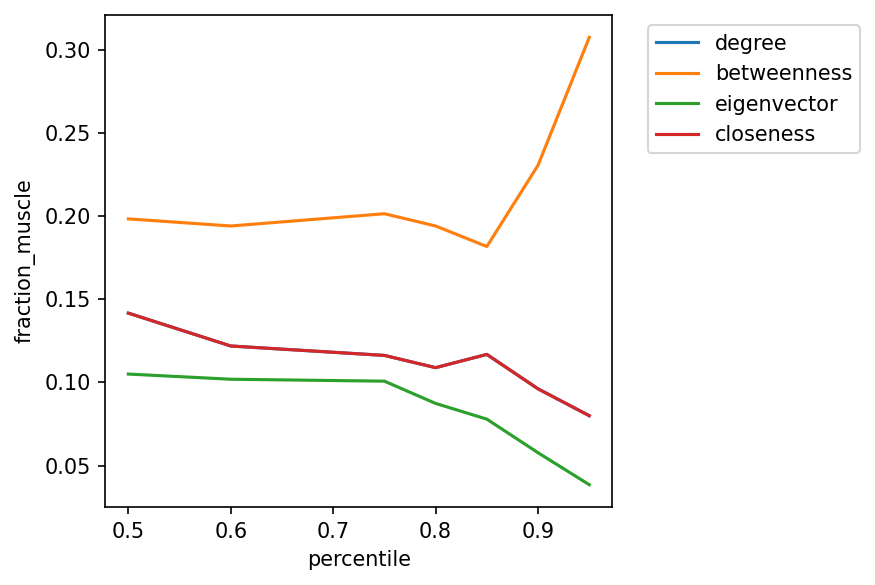

In [106]:
centrality_cols = ['degree', 'betweenness', 'eigenvector', 'closeness']#, 'clustering']
percentiles = [0.5, 0.6, 0.75, 0.8, 0.85, 0.9, 0.95]  # adjust as needed

results = []

for t in percentiles:
    for col in centrality_cols:
        thresh = mdf1[col].quantile(t)
        
        mask = (mdf1[col] > thresh)
        muscle_mask = mask & (mdf1['is_mark_muscle'])
        
        total = mask.sum()
        count = muscle_mask.sum()
        
        results.append({
            'measure': col,
            'percentile': t,
            'threshold': thresh,
            'n_total_above_thresh': total,
            'n_muscle_markers': count,
            'fraction_muscle': count / total if total > 0 else 0
        })

res_df = pd.DataFrame(results)
display(res_df.tail())


plt.rcParams['figure.figsize'] = 6, 4

sns.lineplot(
    res_df,
    x='percentile',
    y='fraction_muscle',
    hue='measure',
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [113]:
def enrichment_curve_auc(df, score_col, marker_col='is_mark_muscle', percentiles=np.linspace(0.8, 0.99, 50)):
    vals = []
    
    for p in percentiles:
        thresh = df[score_col].quantile(p)
        top = df[df[score_col] >= thresh]
        if len(top) == 0:
            vals.append(0)
        else:
            vals.append(top[marker_col].mean())
    
    return np.trapezoid(vals, percentiles)

centrality_cols = ['degree', 'betweenness', 'eigenvector', 'closeness']

auc_scores = {
    col: enrichment_curve_auc(mdf1, col)
    for col in centrality_cols
}
auc_scores

{'degree': np.float64(0.020253032994318132),
 'betweenness': np.float64(0.046618549401245615),
 'eigenvector': np.float64(0.012935115849822158),
 'closeness': np.float64(0.020253032994318132)}

In [108]:
# of the top k ranked genes, what fraction are muscle markers?
def precision_at_k(df, score_col, k=100):
    topk = df.sort_values(score_col, ascending=False).head(k)
    return topk['is_mark_muscle'].mean()

k_vals = [50, 100, 250, 500]

precision_df = pd.DataFrame({
    col: [precision_at_k(mdf1, col, k) for k in k_vals]
    for col in centrality_cols
}, index=k_vals)

precision_df

,degree,betweenness,eigenvector,closeness
50,0.08,0.240,0.060,0.08
100,0.11,0.180,0.080,0.11
250,0.14,0.192,0.104,0.14
500,0.18,0.180,0.180,0.18


In [109]:
from sklearn.metrics import roc_auc_score

aucroc = {
    col: roc_auc_score(mdf1['is_mark_muscle'], mdf1[col])
    for col in centrality_cols
}
aucroc

{'degree': 0.48919025157232704,
 'betweenness': 0.5843815513626834,
 'eigenvector': 0.37997903563941304,
 'closeness': 0.48919025157232704}

In [110]:
from sklearn.metrics import average_precision_score

prauc = {
    col: average_precision_score(mdf1['is_mark_muscle'], mdf1[col])
    for col in centrality_cols
}
prauc

{'degree': 0.1706666376048086,
 'betweenness': 0.23496823671785733,
 'eigenvector': 0.14468380606579395,
 'closeness': 0.1706666376048086}

# Housekeeping genes

In [154]:
# ------- Load housekeeping -------
hpath = "../../resources/HouseKeeping-GeneCards.csv"

hdf = pd.read_csv(hpath)
print(hdf.shape)
hdf.head()

all_hk_genes = hdf['Gene Symbol'].unique()
print(f"N housekeeping genes: {len(all_hk_genes)}")

(634, 8)
N housekeeping genes: 634


In [155]:
df1.head()

,degree,degree_cent,clustering,betweenness,eigenvector,closeness
MYOD1,513,1.000000,0.191391,0.176961,0.111928,1.000000
CD99,36,0.070175,0.749206,0.000042,0.012888,0.518182
KDM1A,126,0.245614,0.600508,0.001230,0.045218,0.570000
PDK4,60,0.116959,0.722034,0.000163,0.021466,0.531056
CALCR,26,0.050682,0.800000,0.000014,0.011952,0.513000


In [157]:
df1['is_hk'] = df1.index.isin(all_hk_genes)
df1.head()

,degree,degree_cent,clustering,betweenness,eigenvector,closeness,is_hk
MYOD1,513,1.000000,0.191391,0.176961,0.111928,1.000000,False
CD99,36,0.070175,0.749206,0.000042,0.012888,0.518182,False
KDM1A,126,0.245614,0.600508,0.001230,0.045218,0.570000,False
PDK4,60,0.116959,0.722034,0.000163,0.021466,0.531056,False
CALCR,26,0.050682,0.800000,0.000014,0.011952,0.513000,False


In [159]:
print(df1['is_hk'].sum())

66


In [160]:
df1.sort_values(by='eigenvector', ascending=False).head(10)

,degree,degree_cent,clustering,betweenness,eigenvector,closeness,is_hk
MYOD1,513,1.000000,0.191391,0.176961,0.111928,1.000000,False
GAPDH,354,0.690058,0.326419,0.021621,0.102716,0.763393,True
CTNNB1,331,0.645224,0.360341,0.014946,0.101326,0.738129,False
MYC,325,0.633528,0.370522,0.012491,0.100720,0.731812,True
ACTB,331,0.645224,0.351588,0.018058,0.099754,0.738129,True
TP53,326,0.635478,0.359037,0.014625,0.099489,0.732857,True
AKT1,308,0.600390,0.394560,0.009271,0.098596,0.714485,False
JUN,270,0.526316,0.454578,0.005352,0.092387,0.678571,True
CCND1,260,0.506823,0.473923,0.004562,0.090783,0.669713,True
ESR1,263,0.512671,0.452065,0.006572,0.089559,0.672346,True
